In [35]:
# import packages
import nltk
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim
from transformers import BertTokenizer

c:\Users\UPPL - 01\Downloads\Anaconda-coding\envs\bert-20\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preprocess text data

title_cleaned and text_cleaned for typical ML models (e.g. logistic regression, svm)

do NOT use for BERT models - BERT models will work better with tokenized data and encodings that would be too large to store (BertTokenizer)

if want to use BERT, copy and paste the bottom cell of this section when training the model

In [25]:
df = pd.read_csv("datasets/WELFake_Dataset.csv")
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [26]:
df.shape

(72134, 4)

In [27]:
# drop nulls
df = df.dropna()
df = df.drop_duplicates()
df.shape

(71537, 4)

In [28]:
# make lowercase
for index, row in df.iterrows():
    df.at[index, "title_cleaned"] = ''.join([i for i in row["title"].lower() if not i.isdigit()])
    df.at[index, "text_cleaned"] = ''.join([i for i in row["text"].lower() if not i.isdigit()])
       
df.head()

,Unnamed: 0,title,text,label,title_cleaned,text_cleaned
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement on high alert following threat...,no comment is expected from barack obama membe...
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable! obama’s attorney general says mo...,"now, most of the demonstrators gathered last ..."
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"bobby jindal, raised hindu, uses story of chri...",a dozen politically active pastors came here f...
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan : russia unvelis an image of its terrify...,"the rs- sarmat missile, dubbed satan , will re..."
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,about time! christian group sues amazon and sp...,all we can say on this one is it s about time ...


In [29]:
df["title_cleaned"] = df["title_cleaned"].apply(nltk.word_tokenize)
df["text_cleaned"] = df["text_cleaned"].apply(nltk.word_tokenize)
df.head()

,Unnamed: 0,title,text,label,title_cleaned,text_cleaned
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, on, high, alert, following,...","[no, comment, is, expected, from, barack, obam..."
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, !, obama, ’, s, attorney, gener...","[now, ,, most, of, the, demonstrators, gathere..."
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, ,, raised, hindu, ,, uses, sto...","[a, dozen, politically, active, pastors, came,..."
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, :, russia, unvelis, an, image, of, its...","[the, rs-, sarmat, missile, ,, dubbed, satan, ..."
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[about, time, !, christian, group, sues, amazo...","[all, we, can, say, on, this, one, is, it, s, ..."


In [30]:
for index, row in df.iterrows():
    df.at[index, "title_cleaned"] = [w for w in row["title_cleaned"] if re.search(r'^[a-z]+$', w)]
    df.at[index, "text_cleaned"] = [w for w in row["text_cleaned"] if re.search(r'^[a-z]+$', w)]
df.head()

,Unnamed: 0,title,text,label,title_cleaned,text_cleaned
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, on, high, alert, following,...","[no, comment, is, expected, from, barack, obam..."
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, obama, s, attorney, general, sa...","[now, most, of, the, demonstrators, gathered, ..."
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, raised, hindu, uses, story, of...","[a, dozen, politically, active, pastors, came,..."
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, russia, unvelis, an, image, of, its, t...","[the, sarmat, missile, dubbed, satan, will, re..."
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[about, time, christian, group, sues, amazon, ...","[all, we, can, say, on, this, one, is, it, s, ..."


In [31]:
stop_list = set(stopwords.words('english'))
for index, row in df.iterrows():
    df.at[index, "title_cleaned"] = [w for w in row["title_cleaned"] if w not in stop_list]
    df.at[index, "text_cleaned"] = [w for w in row["text_cleaned"] if w not in stop_list]

df.head()

,Unnamed: 0,title,text,label,title_cleaned,text_cleaned
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, high, alert, following, thr...","[comment, expected, barack, obama, members, fy..."
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, obama, attorney, general, says,...","[demonstrators, gathered, last, night, exercis..."
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, raised, hindu, uses, story, ch...","[dozen, politically, active, pastors, came, pr..."
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, russia, unvelis, image, terrifying, ne...","[sarmat, missile, dubbed, satan, replace, flie..."
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[time, christian, group, sues, amazon, splc, d...","[say, one, time, someone, sued, southern, pove..."


In [32]:
# lemmatization
lemmatizer = WordNetLemmatizer()
for index, row in df.iterrows():
    df.at[index, "title_cleaned"] = [lemmatizer.lemmatize(w) for w in row["title_cleaned"]]
    df.at[index, "text_cleaned"] = [lemmatizer.lemmatize(w) for w in row["text_cleaned"]]

df.head()

,Unnamed: 0,title,text,label,title_cleaned,text_cleaned
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, high, alert, following, thr...","[comment, expected, barack, obama, member, fyf..."
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, obama, attorney, general, say, ...","[demonstrator, gathered, last, night, exercisi..."
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, raised, hindu, us, story, chri...","[dozen, politically, active, pastor, came, pri..."
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, russia, unvelis, image, terrifying, ne...","[sarmat, missile, dubbed, satan, replace, fly,..."
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[time, christian, group, sue, amazon, splc, de...","[say, one, time, someone, sued, southern, pove..."


In [33]:
df.to_csv("datasets/text_data.csv", index=False)

In [38]:
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

encoding = tokenizer(
    df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

## Preprocess Image data

the cleaned data will take up a lot of space so copy and paste the code below when training the model

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [5]:
# make images same size
train_ds = tf.keras.utils.image_dataset_from_directory(
    "datasets/CASIA2.0_revised",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"   
)

print(train_ds.class_names)

Found 9555 files belonging to 2 classes.
['Au', 'Tp']


In [6]:
# normalize image data
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

In [7]:
# check whether image sizes are consistent
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Min pixel value: 0.0
Max pixel value: 1.0


In [8]:
# data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

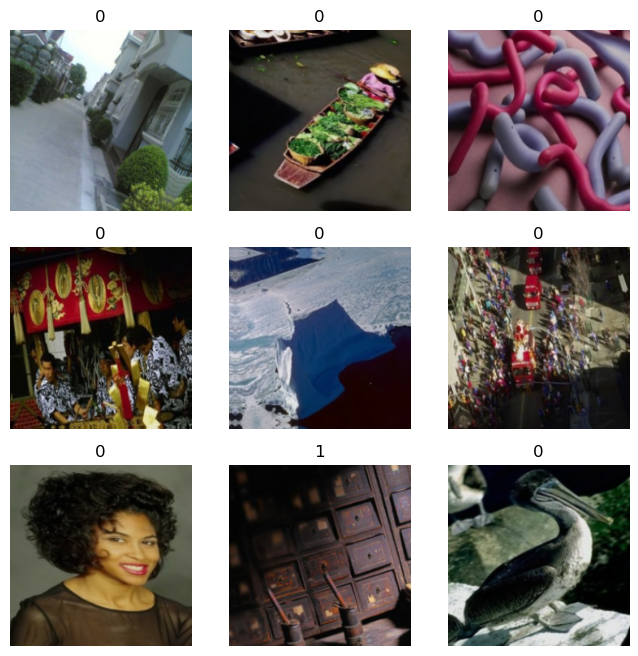

In [10]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(int(labels[i]))
        plt.axis("off")
    plt.show()